# Calculating the Distance Transform


## Description
Once we have a binary image, we can compute a **distance transform**, which measures the distance from each foreground voxel to the nearest background voxel. This is a crucial step in many segmentation pipelines, especially when preparing for watershed segmentation.

There are two common approaches:

- **Exact Euclidean Distance Transform**: This method calculates the true shortest distance from each foreground voxel to the nearest background voxel using Euclidean geometry. It provides precise results and is ideal when accuracy is critical.

- **Chamfer Distance Transform**: This is a fast, approximate method that uses weighted local operations to estimate distances. It’s simpler to implement and easier to understand, making it a good candidate for custom code. While less precise than Euclidean, it is significantly faster and often sufficient for many segmentation tasks.

## Part of Pipeline
- **Previous Step**: Thresholding the image
- **Next Step**: Find seedpoints

## Requirements
- Python 3.11
- Libraries:
  - matplotlib
  - numpy

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from src.visualisation import (
    plot_2d_slice_with_values,
    plot_panels,
)

# Integrate figures into notebook
%matplotlib notebook
%matplotlib inline
plt.close()

### Load the binary image from the previous step

We start by loading up the binary image produced in the previous step.

In [2]:
# Load binary image
binary_image = np.load(file='../src/data/binary_image.npy')


### Step 1 — Chamfer neighbors and weights (26-neighborhood)

We approximate Euclidean distance with a 3D chamfer mask:
- **Faces (6)** → weight = **1.0**
- **Edges (12)** → weight = **√2**
- **Corners (8)** → weight = **√3**

We list **both positive and negative deltas** explicitly for symmetric sweeps.

In [3]:
# Define chamfer mask: each tuple is (dx, dy, dz, weight)
# These represent relative neighbor positions and their associated movement cost.
sqrt2 = np.sqrt(2)
sqrt3 = np.sqrt(3)

# Initialize mask neighbours and weights
neighbours = []
weights = []

# Faces (6)
for dx, dy, dz in [
    ( 1,  0,  0),
    (-1,  0,  0),
    ( 0,  1,  0),
    ( 0, -1,  0),
    ( 0,  0,  1),
    ( 0,  0, -1),
]:
    neighbours.append([dx, dy, dz]); weights.append(1.0)

# Edges (12)
for dx, dy, dz in [
    ( 1,  1,  0), ( 1, -1,  0), (-1,  1,  0), (-1, -1,  0),
    ( 1,  0,  1), ( 1,  0, -1), (-1,  0,  1), (-1,  0, -1),
    ( 0,  1,  1), ( 0,  1, -1), ( 0, -1,  1), ( 0, -1, -1),
]:
    neighbours.append([dx, dy, dz]); weights.append(sqrt2)

# Corners (8)
for dx, dy, dz in [
    ( 1,  1,  1), ( 1,  1, -1), ( 1, -1,  1), ( 1, -1, -1),
    (-1,  1,  1), (-1,  1, -1), (-1, -1,  1), (-1, -1, -1),
]:
    neighbours.append([dx, dy, dz]); weights.append(sqrt3)

neighbours = np.array(neighbours, dtype=int)
weights   = np.array(weights, dtype=float)

print("Total neighbors:", len(neighbours))  #

Total neighbors: 26


### Step 2 — Initialization and padding (distance to nearest background)

We want **inside-object distances**:
- Background (`img == 0`) → **0** (sources)
- Foreground (`img != 0`) → **∞** (to be updated)

We’ll use `float` with `np.inf` to represent “unknown/very large” at sta


In [4]:
# --- Pad with background (zeros) ---
padded = np.pad(binary_image, pad_width=1, mode="constant", constant_values=0)
sx, sy, sz = padded.shape

# Distance FROM BACKGROUND (inverse distance transform)
dt = np.where(padded == 0, 0.0, np.inf).astype(float)

### Step 3 — Sweep order (lexicographic)

We visit **all voxels** in lexicographic order **(x → y → z)** using `np.lexsort`.
Then we do a **forward sweep** and a **backward sweep**:
- Forward: relax from neighbors with **negative deltas** (already visited)
- Backward: relax from neighbors with **positive deltas** (visited in reverse)


In [5]:
# All voxel coordinates
coords = np.argwhere(np.ones_like(padded, dtype=bool))
# np.lexsort: last key is primary → here (x primary, then y, then z)
coords = coords[np.lexsort((coords[:, 2], coords[:, 1], coords[:, 0]))]

### Step 4 — Forward sweep

For each voxel `(x,y,z)`, we check every neighbor `(dx,dy,dz)` and update: $dt[x,y,z] \leftarrow \min\big(dt[x,y,z],\ dt[x-dx,\, y-dy,\, z-dz] + w\big)$
only when the neighbor is **in bounds**.

In [6]:
for x, y, z in coords:
    for (dx, dy, dz), w in zip(neighbours, weights):
        nx, ny, nz = x - dx, y - dy, z - dz
        if 0 <= nx < sx and 0 <= ny < sy and 0 <= nz < sz:
            cand = dt[nx, ny, nz] + w
            if cand < dt[x, y, z]:
                dt[x, y, z] = cand


### Step 5 — Backward sweep

Traverse in reverse lexicographic order and update using **positive deltas**: $dt[x,y,z] \leftarrow \min\big(dt[x,y,z],\ dt[x+dx,\, y+dy,\, z+dz] + w\big)$

In [7]:
for x, y, z in coords[::-1]:
    for (dx, dy, dz), w in zip(neighbours, weights):
        nx, ny, nz = x + dx, y + dy, z + dz
        if 0 <= nx < sx and 0 <= ny < sy and 0 <= nz < sz:
            cand = dt[nx, ny, nz] + w
            if cand < dt[x, y, z]:
                dt[x, y, z] = cand

### Step 6 — Visualize and check

- Distances should be **0 on background voxels**
- Distances should be **finite inside** the foreground
- Distances should be **non-negative** and grow smoothly away from the back


DT stats — min/max/mean: 0.0 4.242640687119286 0.12995341185978798


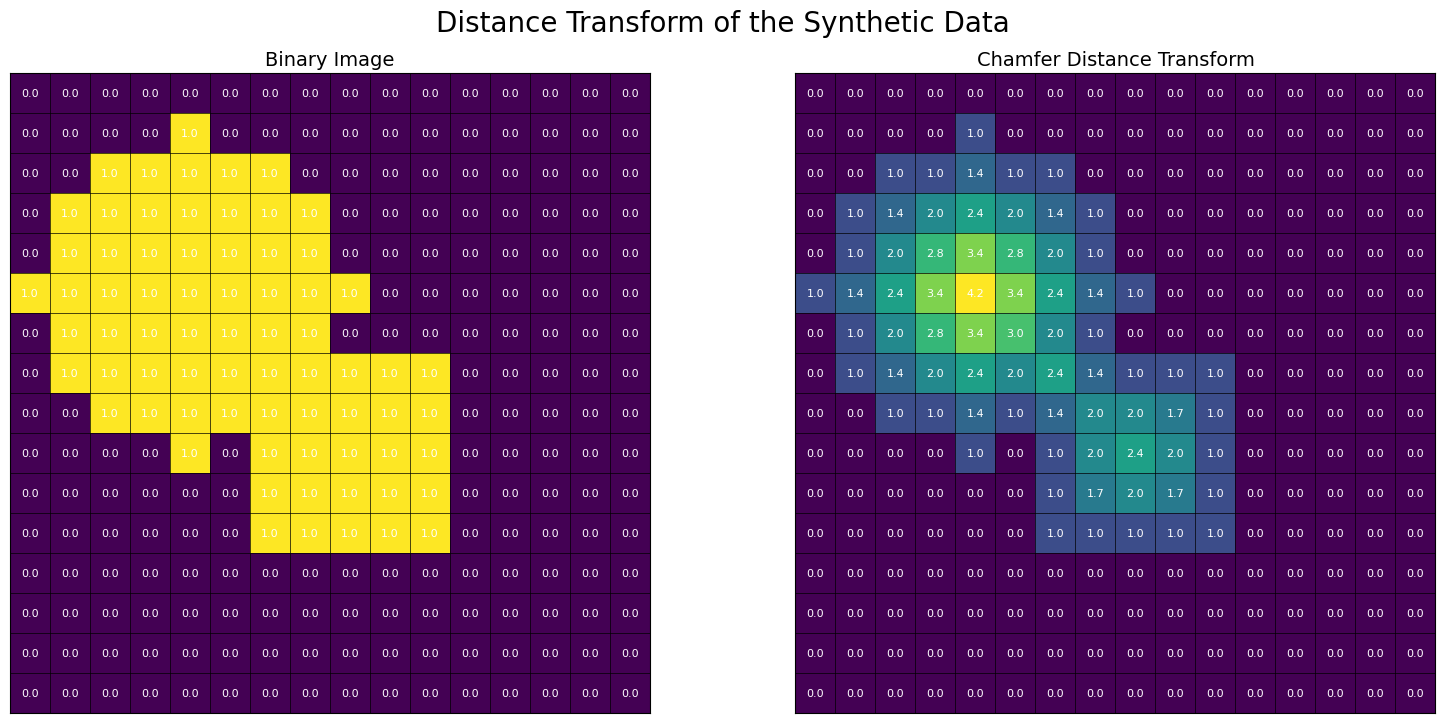

In [8]:
# --- Unpad back to original shape ---
dt = dt[1:-1, 1:-1, 1:-1]

print("DT stats — min/max/mean:", float(np.nanmin(dt)), float(np.nanmax(dt)), float(np.nanmean(dt)))
assert np.all(dt[binary_image == 0] == 0.0), "Background must have zero distance"
assert np.isfinite(dt[binary_image != 0]).all(), "Foreground distances should be finite after sweeps"
assert dt.min() >= 0.0, "Distances must be non-negative"

# Write distance transfrom out
np.save(file='../src/data/distance_transform.npy', arr=dt)

# Visualize a single 2D slice of the distance transform
plot_slice_index = 7 # Slice index to be visualised
plot_panels(
    n=2,
    data_list=[binary_image,dt],
    plot_func=plot_2d_slice_with_values,
    plot_kwargs_list=[{"slice_index": plot_slice_index},{"slice_index": plot_slice_index}],
    title="Distance Transform of the Synthetic Data",
    subtitles=["Binary Image","Chamfer Distance Transform"]
)


**Exercise 1:** Replace weights `(1, √2, √3)` that approximate the Euclidian distance most closely, with integer weights `(3, 4, 5)` and recompute the DT.
Compare both results:
- Do differences show up more near corners or flat faces?

**Exercise 2:** Plot a histogram of DT values **inside the foreground** only.
- Where is the peak?
- Does it match expected radius/thickness of your synthetic shapes?
